In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Bankloan.csv to Bankloan.csv


The head of the dataset is:
   age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   30       487         2    999         0          -1.8          92.893   
1   39       346         4    999         0           1.1          93.994   
2   25       227         1    999         0           1.4          94.465   
3   38        17         3    999         0           1.4          94.465   
4   47        58         1    999         0          -0.1          93.200   

   cons.conf.idx  euribor3m  nr.employed  ...  month_may  month_nov  \
0          -46.2      1.313       5099.1  ...       True      False   
1          -36.4      4.855       5191.0  ...       True      False   
2          -41.8      4.962       5228.1  ...      False      False   
3          -41.8      4.959       5228.1  ...      False      False   
4          -42.0      4.191       5195.8  ...      False       True   

   month_oct  month_sep  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
0   

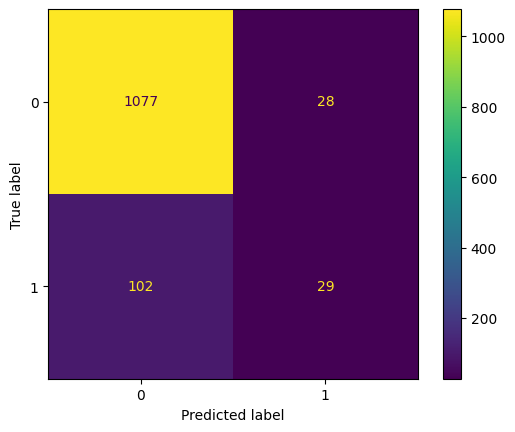

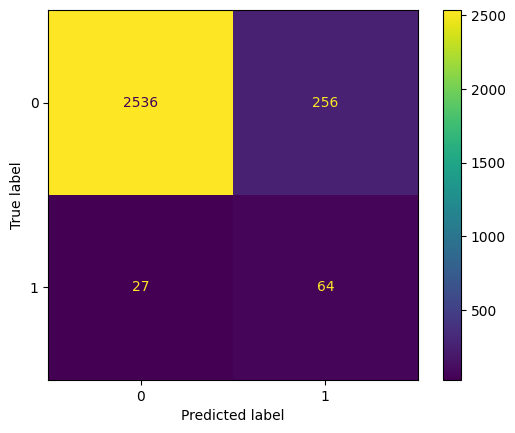

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt


a = pd.read_csv('Bankloan.csv')


target_column = 'y'
X = a.drop(target_column, axis=1)
y = a[target_column]


X = pd.get_dummies(X, drop_first=True)

# Manually encode target if needed
if y.dtype == 'object':
    y = y.astype('category').cat.codes

# Show the preprocessed data
print("The head of the dataset is:")
print(X.head())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the model
model = DecisionTreeClassifier(random_state=42,max_depth=2)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate test performance
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Evaluate training performance
y_train_pred = model.predict(X_train)
cm_train = confusion_matrix(y_train_pred, y_train)
acc_train = accuracy_score(y_train_pred, y_train)
prec_train = precision_score(y_train_pred, y_train)
rec_train = recall_score(y_train_pred, y_train)
f1_train = f1_score(y_train_pred, y_train)

# Print results
print("\nTest Confusion Matrix:")
print(cm)
print("Test Accuracy:", acc)
print("Test Precision:", prec)
print("Test Recall:", rec)
print("Test F1 Score:", f1)

print("\nTrain Confusion Matrix:")
print(cm_train)
print("Train Accuracy:", acc_train)
print("Train Precision:", prec_train)
print("Train Recall:", rec_train)
print("Train F1 Score:", f1_train)

# Display confusion matrices
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.show()

display = ConfusionMatrixDisplay(confusion_matrix=cm_train)
display.plot()
plt.show()
